In [ ]:
import math
from functools import partial
from typing import Any, Callable, List, Optional, Sequence

import torch
from torch import nn, Tensor
from torchvision.models.mobilenetv3 import (
    MobileNetV3,
    InvertedResidualConfig,
    _mobilenet_v3_conf,
    _mobilenet_v3,
)

In [ ]:
#############################################
# Helper Function for Dynamic GroupNorm Calculation
#############################################
def compute_groups(channels, target_groups):
    if channels % target_groups == 0:
        return target_groups
    for g in range(min(target_groups, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1

#############################################
# 1. Define the ELA-S Module (Efficient Local Attention - Small Variant)
#############################################
class ELA_S(nn.Module):
    """
    Efficient Local Attention - Small (ELA-S) module.

    This variant uses:
      - A 1D convolution with kernel size = 5
      - Group Convolution with groups = in_channels/8 (i.e. a slight grouping instead of full depthwise)
      - GroupNorm with a target of 16 groups (dynamically computed)

    It processes the horizontally and vertically pooled feature vectors,
    then reweights the input feature map.
    """
    def __init__(self, inp, kernel_size=5, target_gn_groups=16):
        super(ELA_S, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        pad = kernel_size // 2
        # Use group convolution with groups = inp/8
        groups = max(1, inp // 8)
        self.conv = nn.Conv1d(inp, inp, kernel_size=kernel_size,
                              padding=pad, groups=groups, bias=False)
        # Compute the number of groups for GN without changing the channel count.
        gn_groups = compute_groups(inp, target_gn_groups)
        self.gn = nn.GroupNorm(gn_groups, inp)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.size()
        # Pool along height and width to obtain 1D feature vectors.
        x_h = self.pool_h(x).view(b, c, h)
        x_w = self.pool_w(x).view(b, c, w)
        # Apply 1D convolution, GroupNorm, and sigmoid activation.
        a_h = self.conv(x_h)
        a_h = self.gn(a_h)
        a_h = self.sigmoid(a_h).view(b, c, h, 1)
        a_w = self.conv(x_w)
        a_w = self.gn(a_w)
        a_w = self.sigmoid(a_w).view(b, c, 1, w)
        # Reweight the original feature map.
        return x * a_h * a_w

In [ ]:
#############################################
# 2. Define Inverted Residual Block with ELA-S (InvertedResidualELA_S)
#############################################
class InvertedResidualELA_S(nn.Module):
    """
    Inverted Residual block for MobileNetV3 that uses ELA-S in place of SE when use_se is True.
    """
    def __init__(
        self,
        cnf: InvertedResidualConfig,
        norm_layer: Callable[..., nn.Module],
        attn_layer: Optional[Callable[..., nn.Module]] = None  # We'll pass ELA_S here.
    ):
        super().__init__()
        if not (1 <= cnf.stride <= 2):
            raise ValueError("illegal stride value")
        # Use residual connection if stride == 1 and input channels match output channels.
        self.use_res_connect = cnf.stride == 1 and cnf.input_channels == cnf.out_channels
        layers: List[nn.Module] = []
        activation_layer = nn.Hardswish if cnf.use_hs else nn.ReLU

        # Expansion phase.
        if cnf.expanded_channels != cnf.input_channels:
            layers.append(nn.Sequential(
                nn.Conv2d(cnf.input_channels, cnf.expanded_channels, kernel_size=1, bias=False),
                norm_layer(cnf.expanded_channels),
                activation_layer(inplace=True)
            ))
        # Depthwise convolution.
        stride = 1 if cnf.dilation > 1 else cnf.stride
        layers.append(nn.Sequential(
            nn.Conv2d(cnf.expanded_channels, cnf.expanded_channels,
                      kernel_size=cnf.kernel,
                      stride=stride,
                      padding=cnf.kernel // 2,
                      dilation=cnf.dilation,
                      groups=cnf.expanded_channels,
                      bias=False),
            norm_layer(cnf.expanded_channels),
            activation_layer(inplace=True)
        ))
        # Attention module: if use_se is True, insert our ELA-S.
        if cnf.use_se:
            if attn_layer is not None:
                layers.append(attn_layer(cnf.expanded_channels))
            else:
                from torchvision.models.mobilenetv3 import SqueezeExcitation as SElayer
                from torchvision.models.mobilenetv3 import _make_divisible
                squeeze_channels = _make_divisible(cnf.expanded_channels // 4, 8)
                layers.append(SElayer(cnf.expanded_channels, squeeze_channels))
        # Projection phase.
        layers.append(nn.Sequential(
            nn.Conv2d(cnf.expanded_channels, cnf.out_channels, kernel_size=1, bias=False),
            norm_layer(cnf.out_channels)
        ))
        self.block = nn.Sequential(*layers)
        self.out_channels = cnf.out_channels

    def forward(self, x: Tensor) -> Tensor:
        out = self.block(x)
        if self.use_res_connect:
            out += x
        return out

In [ ]:
#############################################
# 3. Build MobileNetV3 Large with ELA-S Module
#############################################
def mobilenet_v3_ela_s_large(*, weights: Optional[Any] = None, progress: bool = True, **kwargs: Any) -> MobileNetV3:
    """
    Constructs a MobileNetV3 large network that integrates the ELA-S module in place of the original SE blocks.

    Args:
      weights: Optional pretrained weights.
      progress: If True, display a progress bar.
      **kwargs: Additional arguments for MobileNetV3.
    """
    # Retrieve configuration for MobileNetV3 large.
    inverted_residual_setting, last_channel = _mobilenet_v3_conf("mobilenet_v3_large", **kwargs)
    # Use our custom block with ELA-S; replace blocks with use_se==True.
    block = lambda cnf, norm_layer: InvertedResidualELA_S(cnf, norm_layer, attn_layer=ELA_S)
    model = MobileNetV3(inverted_residual_setting, last_channel, block=block, **kwargs)
    # Optionally load pretrained weights (using strict=False to ignore key mismatches).
    if weights is not None:
        state_dict = weights.get_state_dict(progress=progress, check_hash=True)
        model.load_state_dict(state_dict, strict=False)
    return model

In [ ]:
import os
import zipfile
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
class GradCAMWrapper:
    def __init__(self, model):
        self.model = model
        # Here, we point to the last feature layer from model.features rather than model.model.features
        self.target_layers = [self.model.features[-1]]
        self.cam = GradCAM(model=self.model,
                           target_layers=self.target_layers,
                           #use_cuda=torch.cuda.is_available()
                           )

    def visualize(self, input_tensor, rgb_img=None):
        grayscale_cam = self.cam(input_tensor=input_tensor)
        grayscale_cam = grayscale_cam[0, :]
        if rgb_img is None:
            rgb_img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        return visualization

In [ ]:
# ----------------------------
# Data loader, training, and evaluation functions
def get_data_loaders(data_dir, batch_size=32, img_size=(256, 256)):
    train_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    val_test_transforms = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), val_test_transforms)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), val_test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

    return train_loader, val_loader, test_loader

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, device, scheduler=None):
    model.to(device)
    best_val_acc = 0.0
    best_model_path = 'best_model.pth'

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        epoch_time = time.time() - start_time
        samples_per_sec = total / epoch_time

        print(f"Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.2f}s | {samples_per_sec:.2f} samples/s")

        if scheduler:
            scheduler.step(epoch)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved to {best_model_path}")

    # Plot training and validation loss curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training and validation accuracy curves
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_true_vs_predicted(model, test_loader, device, class_names, num_examples=8, model_path='best_model.pth', inputs_batch=None, labels_batch=None):
    model.load_state_dict(torch.load(model_path))
    model.to(device).eval()

    # use provided batch if available, otherwise grab a new one
    if inputs_batch is None or labels_batch is None:
        inputs, labels = next(iter(test_loader))
    else:
        inputs, labels = inputs_batch, labels_batch

    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    # Denormalize images for visualization
    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        plt.subplot(4, 4, idx + 1)
        plt.imshow(img)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def show_gradcam_examples(model, test_loader, device, class_names, num_examples=8, model_path="best_model.pth", inputs_batch=None, labels_batch=None):
    model.load_state_dict(torch.load(model_path))
    model.to(device).eval()
    cam_wrapper = GradCAMWrapper(model)

    # same idea here
    if inputs_batch is None or labels_batch is None:
        inputs, labels = next(iter(test_loader))
    else:
        inputs, labels = inputs_batch, labels_batch

    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    def denormalize(image):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return image * std + mean

    plt.figure(figsize=(12, 12))
    for idx in range(num_examples):
        img = denormalize(inputs[idx]).cpu().permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        visualization = cam_wrapper.visualize(inputs[idx].unsqueeze(0), img)

        plt.subplot(4, 4, idx + 1)
        plt.imshow(visualization)
        plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, test_loader, device, class_names, model_path='best_model.pth'):
    """
    Evaluates the model on the test dataset.

    Args:
        model: The model to evaluate.
        test_loader: DataLoader for the test dataset.
        device: The device to use for computation (e.g., 'cuda' or 'cpu').
        class_names: A list of class names.
        model_path: Path to the model file to load. Defaults to 'best_model.pth'.
    """
    model.load_state_dict(torch.load(model_path))  # Load from the specified path
    model.to(device)
    model.eval()

    y_true, y_pred = [], []
    total, correct = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    test_acc = 100 * correct / total
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [ ]:
# ----------------------------
# Mount Google Drive and prepare dataset paths
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/My Datasets/Tea_Betel_Leaf_Final_Dataset(1).zip'
extract_path = '/content/data'
batch_size = 16
img_size = (256, 256)
num_classes = 10
num_epochs_initial = 40
learning_rate_initial = 3e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extract dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
data_dir = os.path.join(extract_path, 'Tea_Betel_Leaf_Final_Dataset')
train_loader, val_loader, test_loader = get_data_loaders(data_dir, batch_size, img_size)
class_names = train_loader.dataset.classes

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

In [ ]:
# Build the MobileNetV3 Large model with ELA-L Module.
model = mobilenet_v3_ela_s_large(num_classes=num_classes)
# Load pretrained weights (only matching layers) using strict=False.
pretrained_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
pretrained_state_dict = pretrained_model.state_dict()
model_state_dict = model.state_dict()
for name, param in pretrained_state_dict.items():
    if name in model_state_dict and model_state_dict[name].shape == param.shape:
        model_state_dict[name] = param
model.load_state_dict(model_state_dict, strict=False)
print("Loaded pretrained weights for matching layers.")

Loaded pretrained weights for matching layers.


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
# Print updated model architecture and summary after modifying the classifier
print("\nDetailed Model Architecture (After modifying classifier):")
print(model)
print("\nUpdated Model Summary (After modifying classifier):")
summary(model, input_size=(1, 3, img_size[0], img_size[1]))


Detailed Model Architecture (After modifying classifier):
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidualELA_S(
      (block): Sequential(
        (0): Sequential(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Sequential(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidualELA_S(
      (block): Sequential(
        (0): Sequential(
          (0): Conv2d(16, 64

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualELA_S: 2-2                  [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         464
│    └─InvertedResidualELA_S: 2-3                  [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           3,440
│    └─InvertedResidualELA_S: 2-4                  [1, 24, 64, 64]           --
│    │    └─Sequential: 3-6   

In [ ]:
# ====== Helper Functions for Freezing / Unfreezing ======
def freeze_all_except_classifier_and_attention(model):
    """
    Freeze all parameters in the model except for:
      - Those in the classifier.
      - Those in any attention module (i.e. instances of CoordAtt).
    """
    # Freeze everything first.
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze classifier parameters.
    for name, param in model.named_parameters():
        if "classifier" in name:
            param.requires_grad = True

    # Recursively unfreeze attention modules.
    def unfreeze_attention(module):
        for child in module.children():
            # Change this if your attention module has a different class name.
            if isinstance(child, ELA_S):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)


def unfreeze_last_n_layers_and_attention(model, n):
    """
    Unfreeze the last 'n' parameters (in the order returned by model.named_parameters())
    and ensure that attention (CoordAtt) modules remain trainable.
    """
    # Unfreeze the last n parameters.
    params = list(model.named_parameters())
    for name, param in params[-n:]:
        param.requires_grad = True

    # Also ensure that any parameter from a CoordAtt module is trainable.
    def unfreeze_attention(module):
        for child in module.children():
            if isinstance(child, ELA_S):
                for p in child.parameters():
                    p.requires_grad = True
            else:
                unfreeze_attention(child)
    unfreeze_attention(model)

def unfreeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = True

In [ ]:
# ====== Function to Print Model Summary ======
def print_model_summary(model, input_size=(1, 3, 256, 256)):
    print("\n==== Model Summary ====")
    print(summary(model, input_size=input_size))
    print("=======================\n")

In [ ]:
# ====== Function to Show True vs Predicted Images and GradCAM Visualizations ======
def show_visualizations(model, test_loader, device, class_names):
    print("\nTrue vs Predicted Images:")
    plot_true_vs_predicted(model, test_loader, device, class_names, model_path="best_model.pth")
    print("\nGrad-CAM Visualizations:")
    show_gradcam_examples(model, test_loader, device, class_names, model_path="best_model.pth")

In [ ]:
# ====== Stage 1: Train Only the Classifier ======
print("Stage 1: Training only the classifier layer.")

# Freeze everything except the classifier
freeze_all_except_classifier_and_attention(model)
print_model_summary(model)

Stage 1: Training only the classifier layer.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualELA_S: 2-2                  [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidualELA_S: 2-3                  [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidualELA_S: 2-

Epoch 1/40 | Train Loss: 0.7611 Acc: 73.56% | Val Loss: 0.5638 Acc: 78.71% | Time: 36.40s | 189.74 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.3336 Acc: 88.23% | Val Loss: 0.2945 Acc: 90.87% | Time: 37.53s | 184.03 samples/s
Best model saved to best_model.pth
Epoch 3/40 | Train Loss: 0.2124 Acc: 92.37% | Val Loss: 0.2157 Acc: 93.08% | Time: 34.49s | 200.20 samples/s
Best model saved to best_model.pth
Epoch 4/40 | Train Loss: 0.1675 Acc: 93.92% | Val Loss: 0.1940 Acc: 94.02% | Time: 35.76s | 193.13 samples/s
Best model saved to best_model.pth
Epoch 5/40 | Train Loss: 0.1408 Acc: 94.98% | Val Loss: 0.2068 Acc: 93.62% | Time: 34.64s | 199.36 samples/s
Epoch 6/40 | Train Loss: 0.1146 Acc: 95.74% | Val Loss: 0.2272 Acc: 93.75% | Time: 35.10s | 196.75 samples/s
Epoch 7/40 | Train Loss: 0.0936 Acc: 96.52% | Val Loss: 0.2303 Acc: 93.15% | Time: 34.30s | 201.36 samples/s
Epoch 8/40 | Train Loss: 0.0806 Acc: 97.12% | Val Loss: 0.1792 Acc: 94.69% | Time: 35.42s | 195.00 samples/s
Best model saved to best_model.pth
Epoch 9/40 | Train Loss: 0.0678 Acc: 97.58% | Val Loss: 0.1552 Acc: 94.76% | Time: 35.58s | 194.0

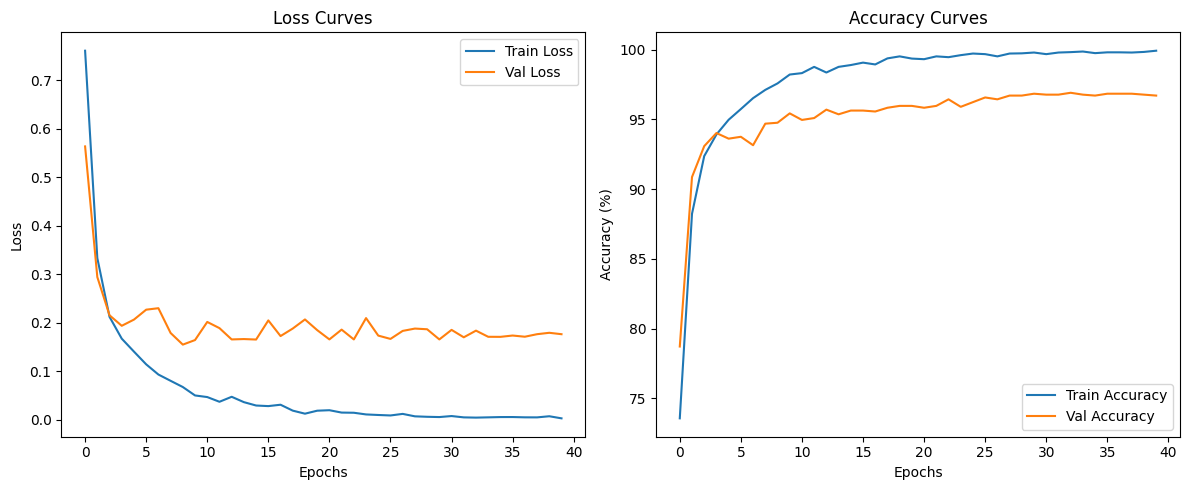

In [ ]:
# Create an optimizer for only trainable parameters
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

# Train the model (use your train_model function)
train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 97.28%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.96      0.95      0.95       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.98      1.00      0.99       148
             betel_Healthy Leaf       0.96      0.95      0.96       148
                 tea_algal_spot       0.97      1.00      0.99       150
               tea_brown_blight       0.89      0.98      0.93       130
                tea_gray_blight       0.99      0.90      0.94       150
                    tea_healthy       0.99      0.99      0.99       150
                 tea_helopeltis       1.00      0.99      0.99       150
                   tea_red_spot       0.98      0.98      0.98       150

                       accuracy                           0.97      1472
                      macro avg       0.97      0.97      0.97      1472
  

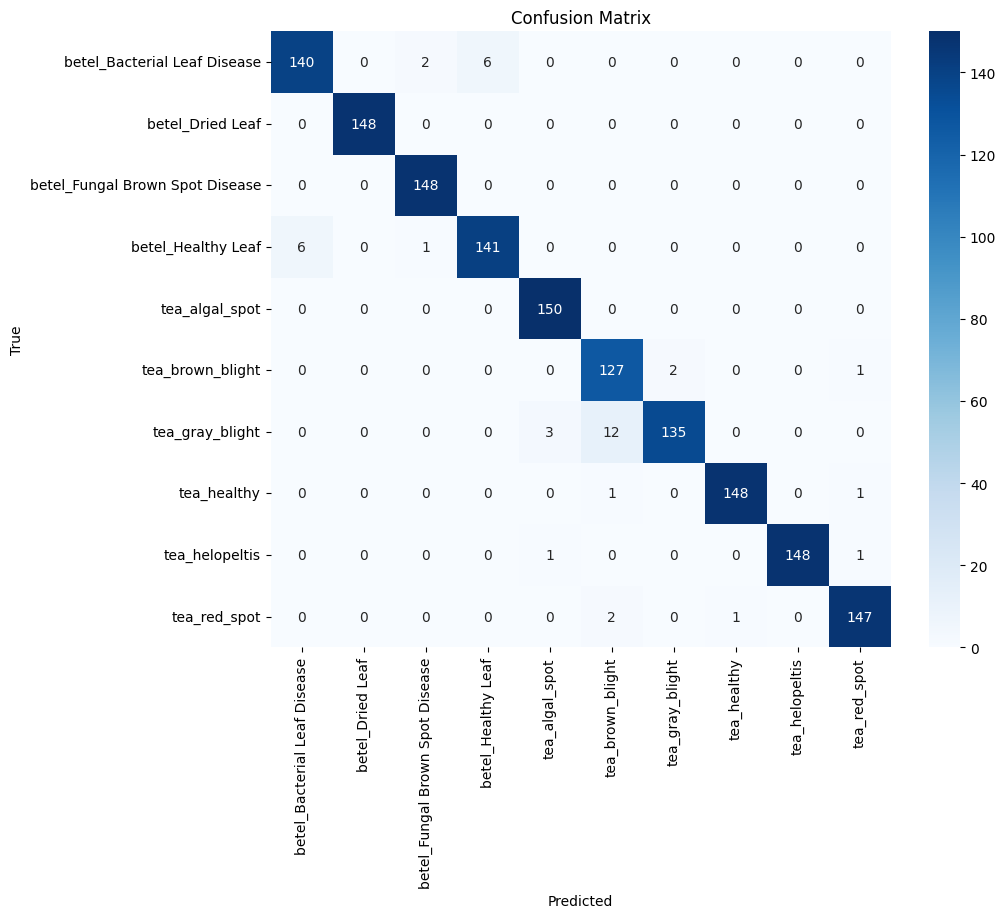

In [ ]:
# Evaluate after Stage 1
evaluate_model(model, test_loader, device, class_names)
#show_visualizations(model, test_loader, device, class_names)

In [ ]:
plot_true_vs_predicted(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
torch.cuda.empty_cache()

In [ ]:
# ====== Stage 2: Fine-Tune the Last N Layers ======
n_layers_to_unfreeze = 20  # Adjust as needed
print(f"\nStage 2: Fine-tuning the last {n_layers_to_unfreeze} layers.")

unfreeze_last_n_layers_and_attention(model, n_layers_to_unfreeze)
print_model_summary(model)


Stage 2: Fine-tuning the last 20 layers.

==== Model Summary ====
Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 10]                   --
├─Sequential: 1-1                                  [1, 960, 8, 8]            --
│    └─Conv2dNormActivation: 2-1                   [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 16, 128, 128]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         (32)
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         --
│    └─InvertedResidualELA_S: 2-2                  [1, 16, 128, 128]         --
│    │    └─Sequential: 3-4                        [1, 16, 128, 128]         (464)
│    └─InvertedResidualELA_S: 2-3                  [1, 24, 64, 64]           --
│    │    └─Sequential: 3-5                        [1, 24, 64, 64]           (3,440)
│    └─InvertedResidualELA_S: 2-4  

Epoch 1/40 | Train Loss: 0.0431 Acc: 98.57% | Val Loss: 0.2158 Acc: 95.63% | Time: 35.98s | 191.92 samples/s
Best model saved to best_model.pth


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 2/40 | Train Loss: 0.0521 Acc: 98.36% | Val Loss: 0.1918 Acc: 94.76% | Time: 34.77s | 198.61 samples/s
Epoch 3/40 | Train Loss: 0.0290 Acc: 98.99% | Val Loss: 0.2288 Acc: 95.63% | Time: 35.14s | 196.51 samples/s
Epoch 4/40 | Train Loss: 0.0365 Acc: 98.74% | Val Loss: 0.2047 Acc: 95.50% | Time: 35.81s | 192.85 samples/s
Epoch 5/40 | Train Loss: 0.0243 Acc: 99.32% | Val Loss: 0.1772 Acc: 95.63% | Time: 34.49s | 200.25 samples/s
Epoch 6/40 | Train Loss: 0.0175 Acc: 99.54% | Val Loss: 0.1453 Acc: 96.51% | Time: 35.10s | 196.75 samples/s
Best model saved to best_model.pth
Epoch 7/40 | Train Loss: 0.0205 Acc: 99.26% | Val Loss: 0.1672 Acc: 96.44% | Time: 34.51s | 200.12 samples/s
Epoch 8/40 | Train Loss: 0.0159 Acc: 99.42% | Val Loss: 0.1927 Acc: 96.57% | Time: 34.95s | 197.62 samples/s
Best model saved to best_model.pth
Epoch 9/40 | Train Loss: 0.0221 Acc: 99.19% | Val Loss: 0.2020 Acc: 95.97% | Time: 35.39s | 195.12 samples/s
Epoch 10/40 | Train Loss: 0.0238 Acc: 99.15% | Val Loss: 0

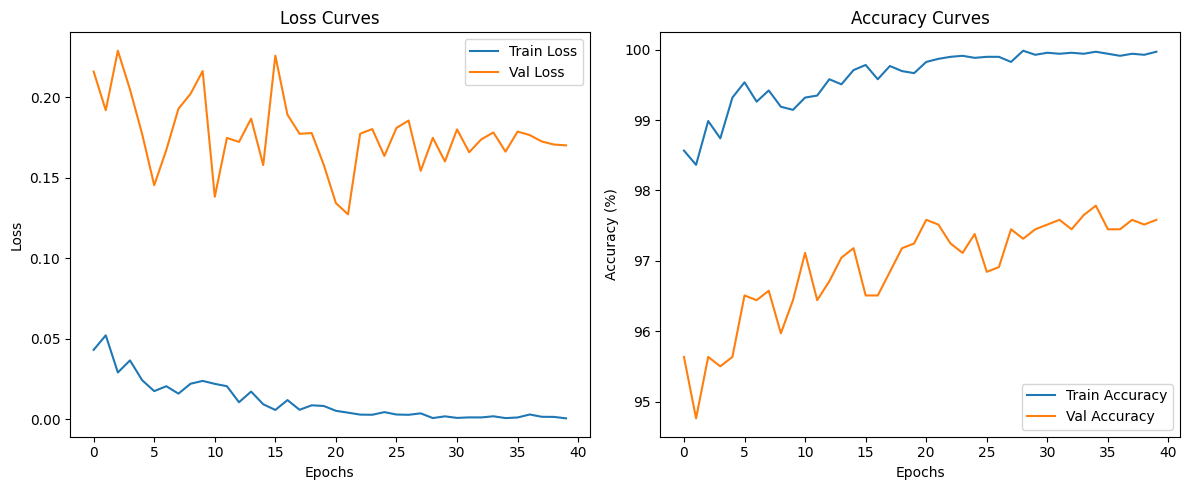

In [ ]:
# Re-create the optimizer with the updated trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate_initial)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_initial)

# Train again
train_model(model, train_loader, val_loader, num_epochs=num_epochs_initial,
            optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)


Test Accuracy: 98.51%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.97      0.95      0.96       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      1.00      0.99       148
             betel_Healthy Leaf       0.97      0.97      0.97       148
                 tea_algal_spot       1.00      0.99      1.00       150
               tea_brown_blight       0.96      0.98      0.97       130
                tea_gray_blight       0.98      0.97      0.97       150
                    tea_healthy       0.99      0.99      0.99       150
                 tea_helopeltis       1.00      0.99      1.00       150
                   tea_red_spot       0.99      1.00      1.00       150

                       accuracy                           0.99      1472
                      macro avg       0.98      0.99      0.98      1472
  

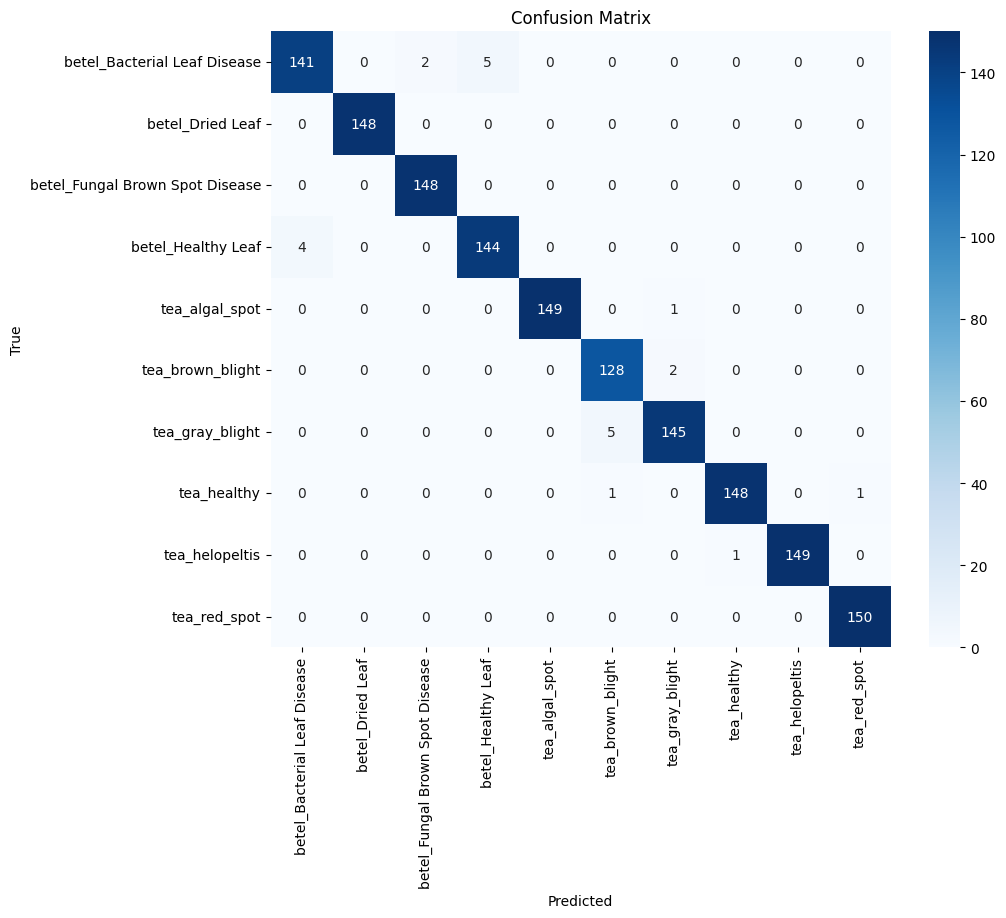

In [ ]:
# Evaluate after Stage 2
evaluate_model(model, test_loader, device, class_names)

In [ ]:
show_visualizations(model, test_loader, device, class_names)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
torch.cuda.empty_cache()

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 103.9 MB/s eta 0:00:00


In [ ]:
import os

# Define the path to your model in the Colab notebook
model_path_colab = 'best_model.pth'

# Define the path where you want to save the model in your Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_elaS_best_model.pth'  # Create the "MyModels" folder if it doesn't exist

# Save the model to Google Drive
try:
    os.makedirs(os.path.dirname(model_path_drive), exist_ok=True)  # Create the directory if it doesn't exist
    !cp "{model_path_colab}" "{model_path_drive}"
    print(f"Model saved to: {model_path_drive}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved to: /content/drive/My Drive/MyModels/mobnetV3_elaS_best_model.pth



Test Accuracy: 98.51%

Classification Report:
                                 precision    recall  f1-score   support

   betel_Bacterial Leaf Disease       0.97      0.95      0.96       148
               betel_Dried Leaf       1.00      1.00      1.00       148
betel_Fungal Brown Spot Disease       0.99      1.00      0.99       148
             betel_Healthy Leaf       0.97      0.97      0.97       148
                 tea_algal_spot       1.00      0.99      1.00       150
               tea_brown_blight       0.96      0.98      0.97       130
                tea_gray_blight       0.98      0.97      0.97       150
                    tea_healthy       0.99      0.99      0.99       150
                 tea_helopeltis       1.00      0.99      1.00       150
                   tea_red_spot       0.99      1.00      1.00       150

                       accuracy                           0.99      1472
                      macro avg       0.98      0.99      0.98      1472
  

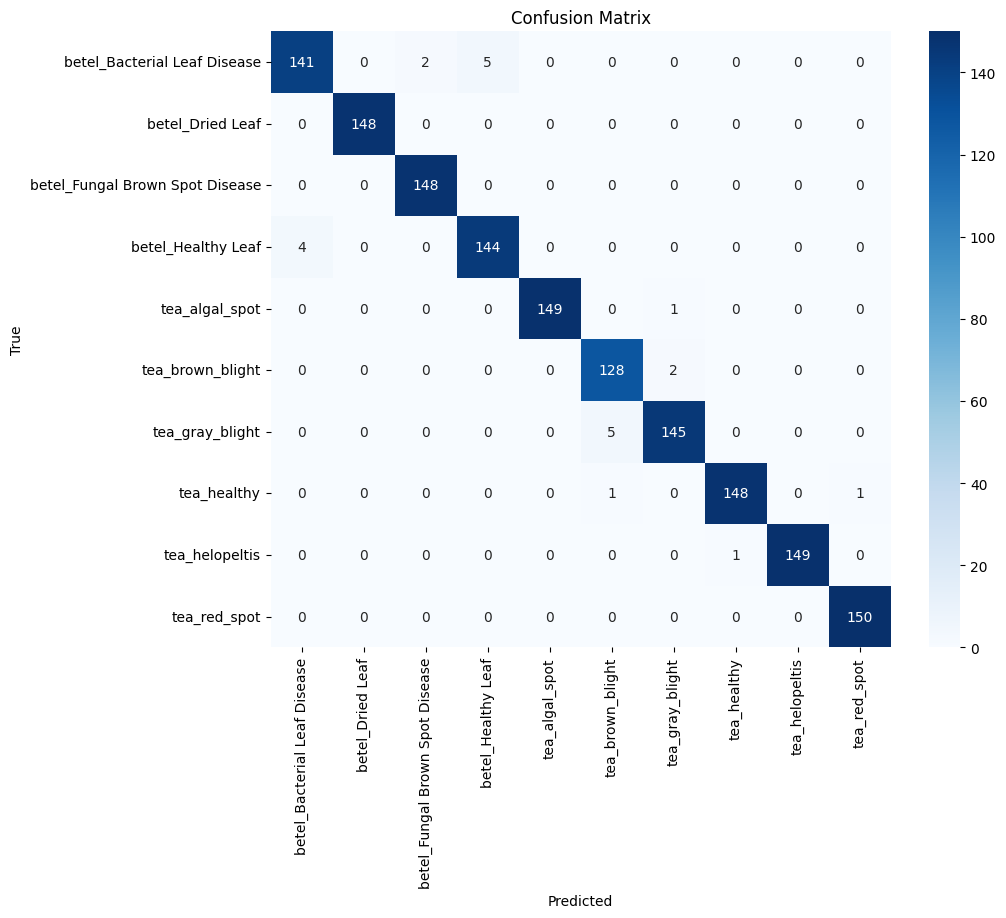

In [ ]:
# Load the saved model from Google Drive
model_path_drive = '/content/drive/My Drive/MyModels/mobnetV3_elaS_best_model.pth'
model.load_state_dict(torch.load(model_path_drive))

# Move the model to the appropriate device
model.to(device)

# Evaluate the model
evaluate_model(model, test_loader, device, class_names, model_path=model_path_drive)

In [ ]:
# Before plotting or visualizing cam:
inputs_batch, labels_batch = next(iter(test_loader))

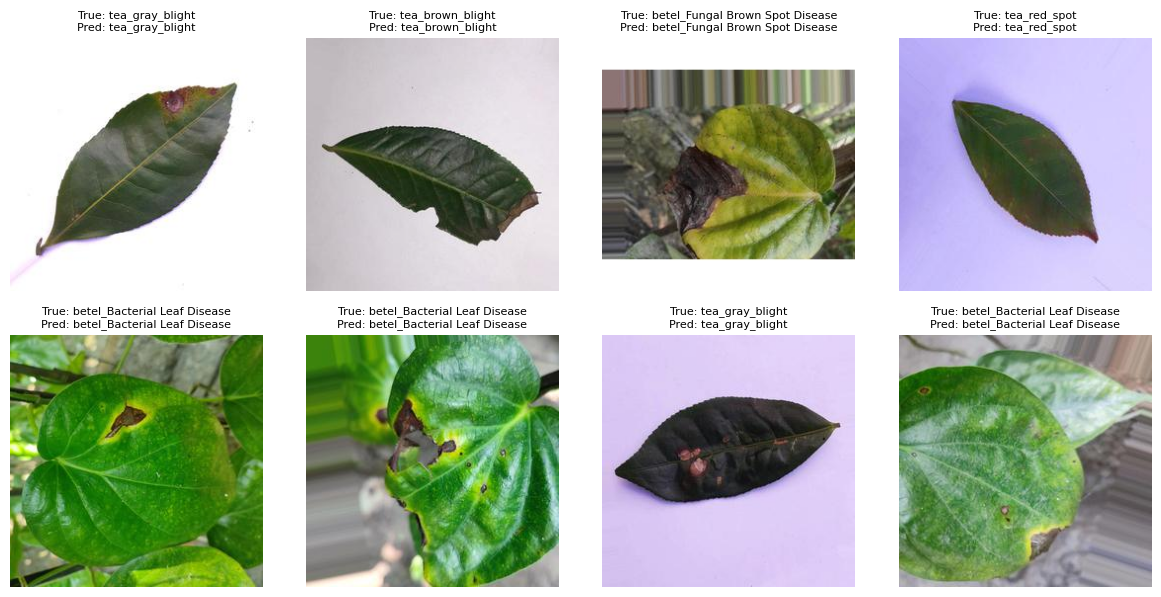

In [ ]:
plot_true_vs_predicted(model, test_loader, device, class_names, model_path=model_path_drive, inputs_batch=inputs_batch, labels_batch=labels_batch)

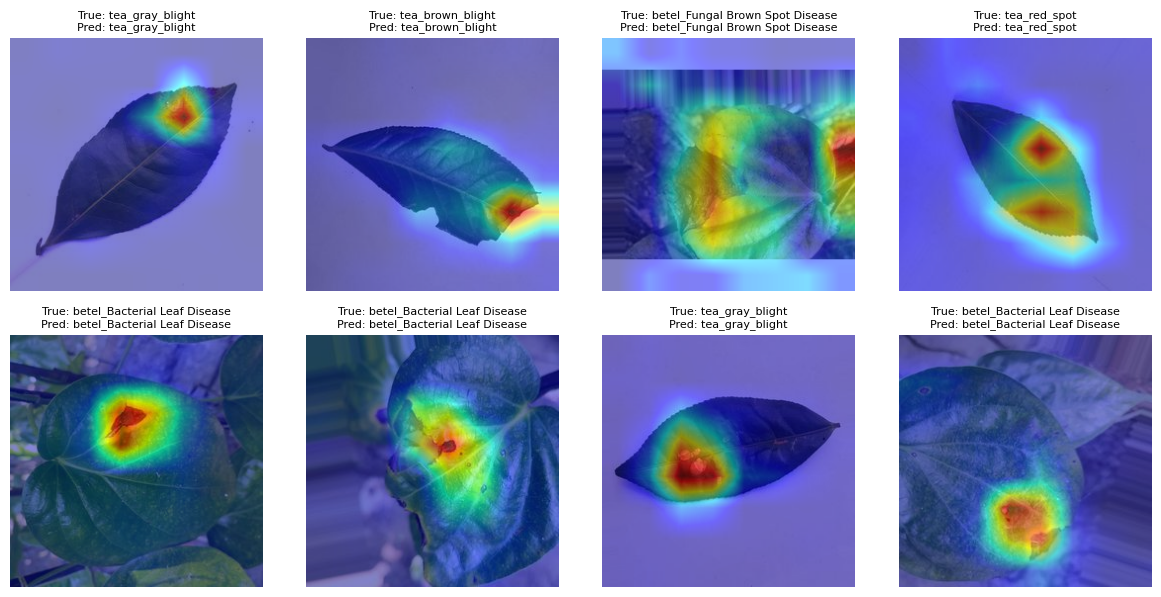

In [ ]:
show_gradcam_examples(model, test_loader, device, class_names, model_path=model_path_drive, inputs_batch=inputs_batch, labels_batch=labels_batch)

In [ ]:
# Determine the input shape your model expects
# For example, if your model takes batches of 3-channel 256x256 images:
dummy_input = torch.randn(1, 3, 256, 256)

# Adjust the shape and data type accordingly
dummy_input = dummy_input.to(next(model.parameters()).device) # Ensure it's on the same device as the model (CPU in this case usually)

In [ ]:
output_path = '/content/drive/My Drive/MyModels/mobnetV3_elaS_best_model.onnx' # Path to save the ONNX file

torch.onnx.export(model,                     # The PyTorch model to be exported
                  dummy_input,               # A sample input tensor
                  output_path,               # Where to save the ONNX model
                  export_params=True,        # Store the trained parameter weights inside the ONNX file
                  opset_version=11,          # The ONNX version to use (try 11 or higher)
                  do_constant_folding=True,  # Optimize constant operations
                  input_names=['input'],     # Name for the input node(s) in the ONNX graph
                  output_names=['output'])   # Name for the output node(s) in the ONNX graph

print(f"ONNX model saved to: {output_path}")

ONNX model saved to: /content/drive/My Drive/MyModels/mobnetV3_elaS_best_model.onnx


In [ ]:
# # ====== Stage 3: Fine-Tune the Entire Model ======
# print("\nStage 3: Fine-tuning the entire model.")
# unfreeze_all_layers(model)
# print_model_summary(model)

In [ ]:
# # Re-create the optimizer to update all parameters
# optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00001)
# scheduler = CosineAnnealingLR(optimizer, T_max=10)

# # Final training stage
# train_model(model, train_loader, val_loader, num_epochs=10,
#             optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)

In [ ]:
# # Final evaluation
# evaluate_model(model, test_loader, device, class_names)

In [ ]:
# show_visualizations(model, test_loader, device, class_names)